### ⚠️ Patched for Local Execution
This notebook was originally designed for Google Colab. It has been automatically patched:
- Google Colab-specific imports and `drive.mount()` calls have been commented out
- Colab file paths (`/content/drive/...`) have been replaced with relative paths (`./`)
- `!pip install` commands have been commented out (install packages in your venv instead)

**To run locally:** activate your Python virtual environment first, then run this notebook in VS Code or Jupyter.

In [1]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

c:\Users\aziz1\OneDrive\Desktop\hsoub academy\ok\02_Google_Colab_Notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 16759.03it/s]
c:\Users\aziz1\OneDrive\Desktop\hsoub academy\ok\02_Google_Colab_Notebooks\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aziz1\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_h

In [2]:
# [PATCHED] from google.colab import drive
# [PATCHED] drive.mount('./')

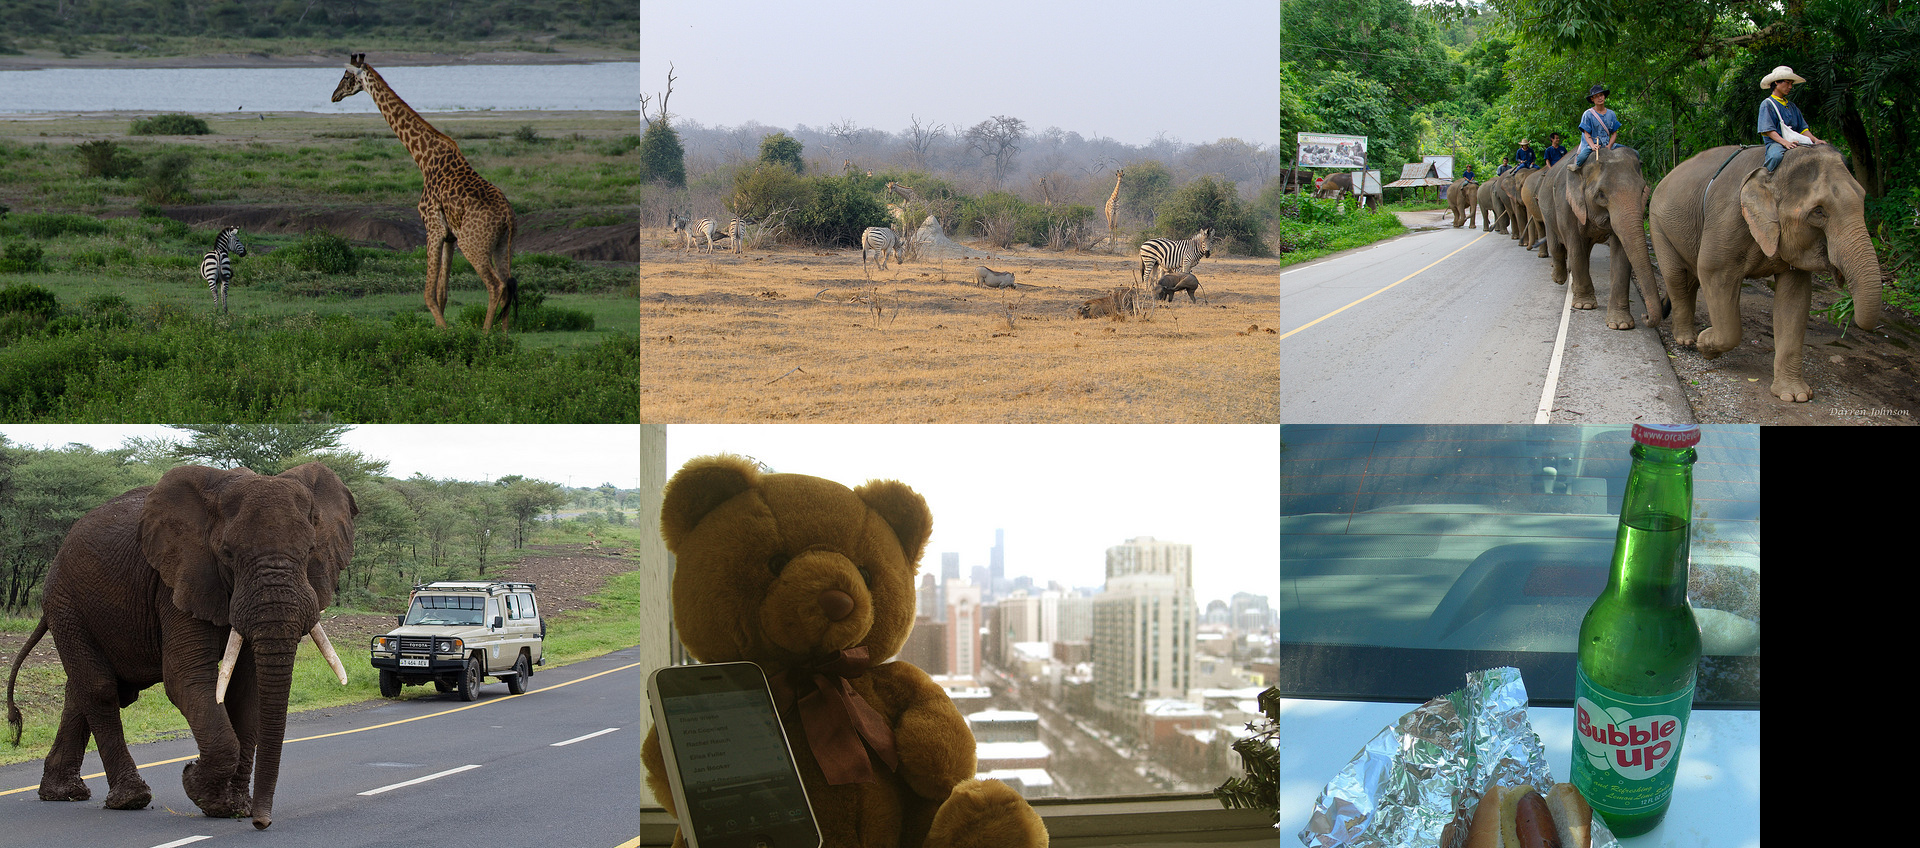

In [3]:
from PIL import Image
import os

def image_grid(imgs, cols):
    rows = (len(imgs) + cols - 1) // cols
    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols * w, rows * h))

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))
    return grid

# Directory containing images
import os
image_folder = './images' if os.path.exists('./images') else 'CLIP_Classification/images'

# Load images from the folder
images = []
for filename in os.listdir(image_folder):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(image_folder, filename)
        images.append(Image.open(img_path))

# Create and display the grid
if images:
    grid = image_grid(images, cols=3)
    display(grid)
else:
    print("No images found in the directory.")

In [4]:
classes = ['giraffe', 'zebra', 'elephant', 'teddybear', 'hotdog']
inputs = processor(text=classes, images=images, return_tensors="pt", padding=True)

outputs = model(**inputs)

In [5]:
logits_per_image = outputs.logits_per_image
logits_per_image

tensor([[26.2749, 24.4344, 19.6651, 14.8109, 14.1720],
        [24.2244, 23.7791, 24.5800, 16.6566, 14.4544],
        [16.9825, 16.9978, 24.7723, 16.4060, 13.8737],
        [23.0416, 19.8457, 27.2316, 18.6049, 15.4245],
        [19.6142, 15.1834, 20.0340, 27.0980, 16.3873],
        [15.0441, 15.2504, 16.5706, 18.6127, 25.9523]], grad_fn=<TBackward0>)

In [6]:
probs = logits_per_image.softmax(dim=1)
probs

tensor([[8.6199e-01, 1.3683e-01, 1.1612e-03, 9.0523e-06, 4.7782e-06],
        [3.2590e-01, 2.0880e-01, 4.6511e-01, 1.6845e-04, 1.8623e-05],
        [4.1349e-04, 4.1986e-04, 9.9892e-01, 2.3232e-04, 1.8463e-05],
        [1.4908e-02, 6.1021e-04, 9.8430e-01, 1.7644e-04, 7.3347e-06],
        [5.6131e-04, 6.6819e-06, 8.5410e-04, 9.9856e-01, 2.2273e-05],
        [1.8293e-05, 2.2484e-05, 8.4186e-05, 6.4882e-04, 9.9923e-01]],
       grad_fn=<SoftmaxBackward0>)

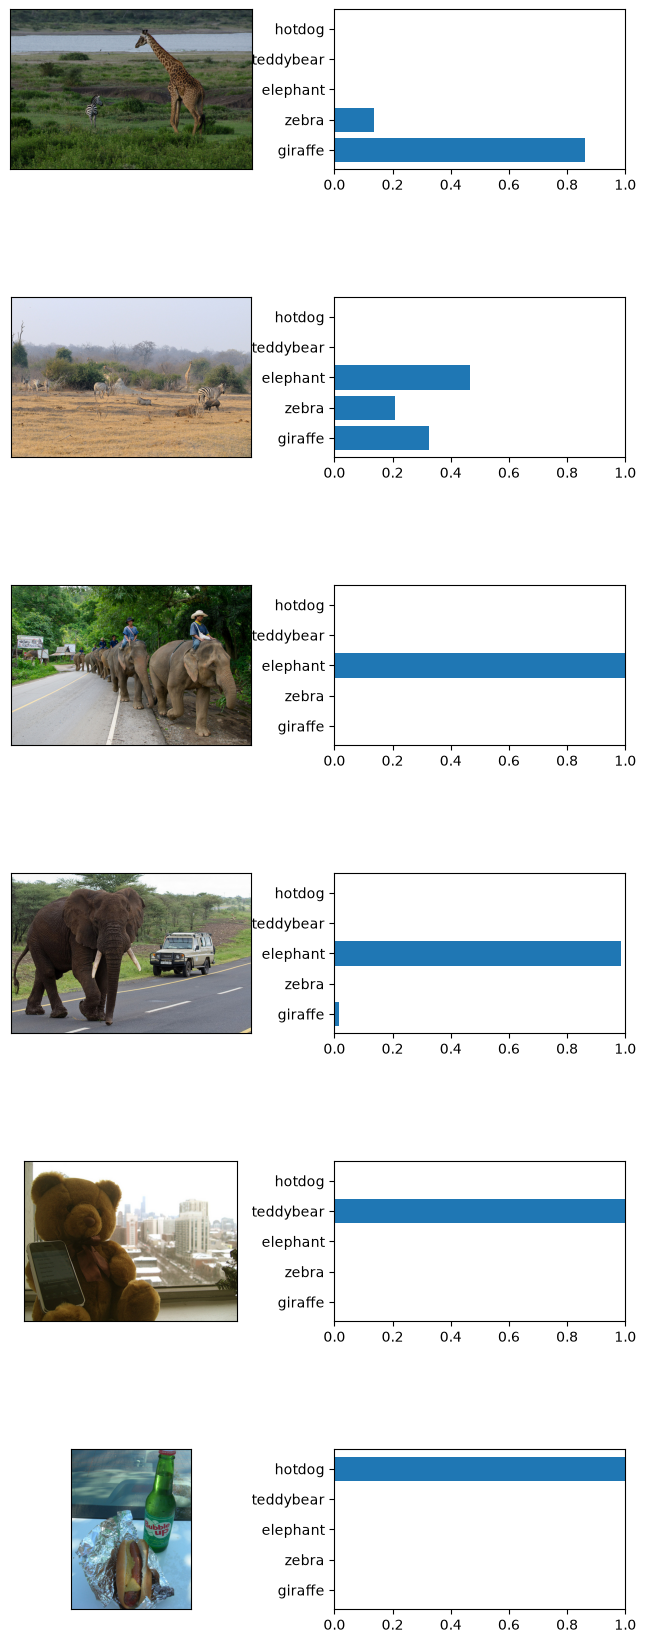

In [7]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 20))

for idx in range(len(images)):

    # show original image
    fig.add_subplot(len(images), 2, 2*(idx+1)-1 )
    plt.imshow(images[idx])
    plt.xticks([])
    plt.yticks([])

  # show probabilities
    fig.add_subplot(len(images), 2, 2*(idx+1))
    plt.barh(range(len(probs[0].detach().numpy())),probs[idx].detach().numpy(), tick_label=classes)
    plt.xlim(0,1.0)

    plt.subplots_adjust(left=0.1,
                        bottom=0.1,
                        right=0.9,
                        top=0.9,
                        wspace=0.2,
                        hspace=0.8)

plt.show()